# 3.6 — Render rollouts in Blender

`scripts/render_blender.py` turns a MyoSuite CPU rollout into an anatomical, studio-lit render in
[Blender](https://www.blender.org/). It exports the episode to animated USD (bones, task objects and
**volumetric muscles**), then builds a Cycles scene: ivory bones, glossy muscles that turn from rose
to deep red as they activate, and a seamless studio backdrop. The muscle look follows the volumetric
visualiser of [MuSkeMo](https://github.com/PashavanBijlert/MuSkeMo).

| | | |
|---|---|---|
| ![leg](../docs/source/images/blender/leg.jpg) | ![hand](../docs/source/images/blender/hand.jpg) | ![elbow](../docs/source/images/blender/elbow.jpg) |
| `myoLegWalk-v0` | `myoHandReorient8-v0` | `myoElbowPose1D6MRandom-v0` |

This notebook covers:
1. exporting a rollout (no Blender needed),
2. what the export contains and how the muscle volumes are computed,
3. rendering a preview frame and a short video,
4. the main options, and rendering a trained policy.

## Requirements

- The USD exporter dependencies: `pip install usd-core` (or `pip install "mujoco[usd]"`).
- Blender 4.5 LTS or newer for steps 3-4 ([download](https://www.blender.org/download/)). Point the
  `BLENDER` environment variable to its executable, or put `blender` on your `PATH`.
  Without Blender, steps 1-2 still run and step 3 shows the reference images above.

In [1]:
import os; _nb = globals().get("__vsc_ipynb_file__"); _nb and os.chdir(os.path.dirname(_nb))  # VS Code: work relative to this notebook

import importlib.util
import json
import shutil
import subprocess
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Video, display
from PIL import Image as PILImage

# The renderer is a script in the repository, next to the tutorials.
SCRIPT = next(
    p.resolve()
    for p in [Path("../scripts/render_blender.py"), Path("scripts/render_blender.py")]
    if p.exists()
)
BLENDER = os.environ.get("BLENDER") or shutil.which("blender")
OUT = Path(tempfile.mkdtemp(prefix="myosuite-blender-"))
print("blender:", Path(BLENDER).name if BLENDER else "not found (steps 3-4 are skipped)")
print("output: ", OUT)


def show(path: Path, width: int) -> None:
    """Display a render as a compact JPEG."""
    jpeg = path.with_suffix(".jpg")
    PILImage.open(path).convert("RGB").save(jpeg, quality=85)
    display(Image(filename=jpeg, width=width))


def render(*args: str) -> None:
    """Run the renderer CLI and print its summary line."""
    cmd = [sys.executable, str(SCRIPT), *args]
    if BLENDER:
        cmd += ["--blender", BLENDER]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode:
        print(result.stdout[-2000:], result.stderr[-2000:])
        result.check_returncode()
    print(next(line for line in result.stdout.splitlines() if line.startswith("Exported")))

blender: blender
output:  /tmp/myosuite-blender-grop67e2


## 1. Export a rollout

`--export-only` runs one CPU episode and writes the USD animation without starting Blender.
`--random` drives the env with random actions; use `--checkpoint` for a trained policy (step 4).
Recording stops at `--seconds` or when the episode terminates.

In [2]:
elbow = OUT / "elbow"
render("--env", "myoElbowPose1D6MRandom-v0", "--random", "--seconds", "1", "--output", str(elbow), "--export-only")
print(sorted(p.name for p in elbow.iterdir()))

Exported 51 samples, 1.000s to /tmp/myosuite-blender-grop67e2/elbow/usd/frames/frame_51.usdc
['muscles.npz', 'reference.npz', 'render.json', 'usd']


## 2. What the export contains

- `usd/frames/frame_N.usdc`: the animated scene (metres, simulation timing), including one tube mesh per muscle.
- `render.json`: render settings and the object lists the Blender stage uses (bones, muscles, scenery).
- `muscles.npz`: muscle activation per control step, which drives the muscle colour.
- `reference.npz`: recorded `qpos` and geom poses, to check the render against the simulation.

51 samples at dt = 0.020 s, 6 muscles, 68 bone meshes


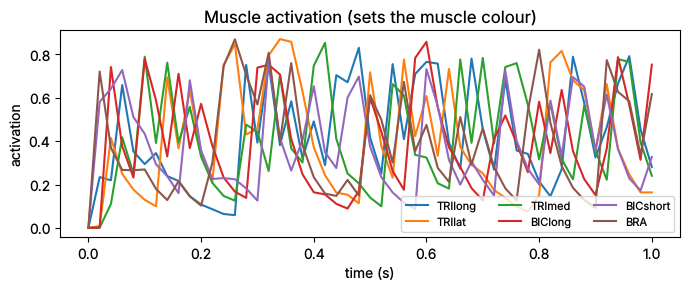

In [3]:
meta = json.loads((elbow / "render.json").read_text())
activation = np.load(elbow / "muscles.npz")["activation"]
t = np.arange(len(activation)) * meta["dt"]
print(f"{meta['samples']} samples at dt = {meta['dt']:.3f} s, {len(meta['muscle_objects'])} muscles, {len(meta['bone_objects'])} bone meshes")

fig, ax = plt.subplots(figsize=(7, 3))
for name, a in zip(meta["muscle_objects"], activation.T):
    ax.plot(t, a, label=name.removeprefix("Muscle_"))
ax.set(xlabel="time (s)", ylabel="activation", title="Muscle activation (sets the muscle colour)")
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()

### Volumetric muscles

Each muscle is a tube along its MuJoCo tendon path. The belly spans 80% of the path, shifted slightly
towards the origin, and the tendons at both ends have 0.3 of the belly radius.

The volume is the MuSkeMo estimate `V = F_max / sigma * L0`, with a specific tension
`sigma = 300 kPa` and the optimal fibre length `L0` (clamped to 5-80% of the path). The volume is fixed
for the episode, so a muscle that shortens gets thicker.

TRIlong  volume  343.8 cm^3, path  29.2 cm, belly radius 27.4 mm
TRIlat   volume  229.3 cm^3, path  18.1 cm, belly radius 28.4 mm
TRImed   volume  229.2 cm^3, path  16.9 cm, belly radius 29.4 mm
BIClong  volume  234.4 cm^3, path  41.0 cm, belly radius 19.1 mm
BICshort volume  186.6 cm^3, path  33.0 cm, belly radius 19.0 mm
BRA      volume  279.2 cm^3, path  13.9 cm, belly radius 35.8 mm


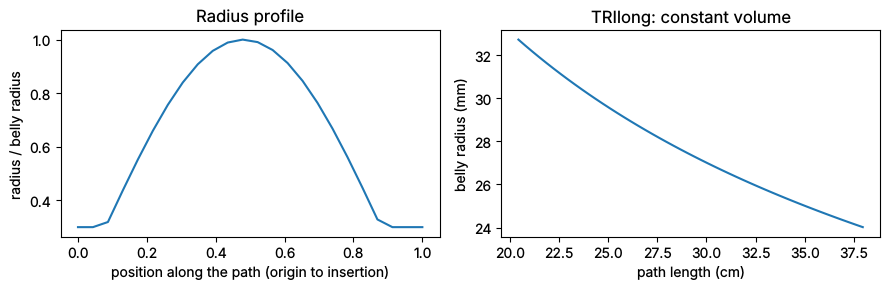

In [4]:
spec = importlib.util.spec_from_file_location("render_blender", SCRIPT)
rb = importlib.util.module_from_spec(spec)
spec.loader.exec_module(rb)

from myosuite import make_env

env = make_env("myoElbowPose1D6MRandom-v0")
env.reset(seed=0)
model, data = env.unwrapped.model, env.unwrapped.data
muscles = rb.muscle_actuators(model)
lengths = data.ten_length[model.actuator_trnid[muscles, 0]]
volumes = rb.muscle_volumes(model, lengths)
profile = rb.radius_profile()
for a, v, length in zip(muscles, volumes, lengths):
    print(f"{model.actuator(a).name:8s} volume {v * 1e6:6.1f} cm^3, path {length * 100:5.1f} cm, belly radius {rb.belly_radius(v, length, profile) * 1000:4.1f} mm")
env.close()

fig, (left, right) = plt.subplots(1, 2, figsize=(9, 3))
s = np.linspace(0, 1, len(profile))
left.plot(s, profile)
left.set(xlabel="position along the path (origin to insertion)", ylabel="radius / belly radius", title="Radius profile")
shortening = np.linspace(0.7, 1.3, 50) * lengths[0]
right.plot(shortening * 100, rb.belly_radius(volumes[0], shortening, profile) * 1000)
right.set(xlabel="path length (cm)", ylabel="belly radius (mm)", title=f"{model.actuator(muscles[0]).name}: constant volume")
plt.tight_layout()

## 3. Render a preview frame

`--preview` renders the first frame to `preview.png` and saves the editable `scene.blend`.
`--samples` sets the Cycles quality (64 by default; 16-32 is enough for a draft).

Exported 21 samples, 0.200s to /tmp/myosuite-blender-grop67e2/leg/usd/frames/frame_21.usdc


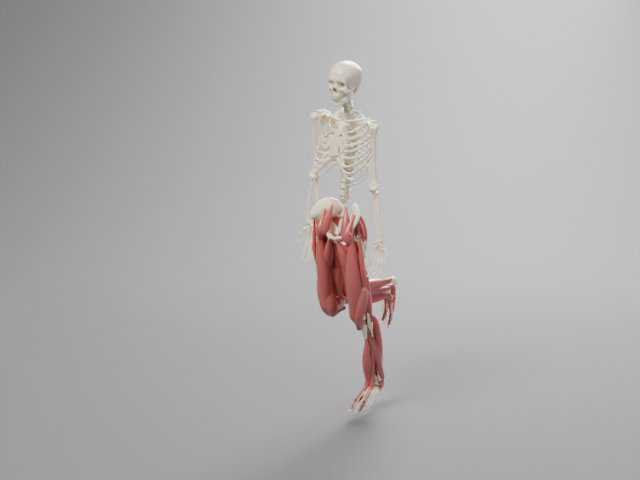

In [5]:
if BLENDER:
    leg = OUT / "leg"
    render("--env", "myoLegWalk-v0", "--random", "--seconds", "0.2", "--preview",
           "--resolution", "640", "480", "--samples", "32", "--output", str(leg))
    show(leg / "preview.png", 640)
else:
    display(Image(filename="../docs/source/images/blender/leg.jpg", width=640))

### A short video

Without `--preview` every frame is rendered and assembled into `video.mp4` at `--fps`.
Rendering is the slow part (Cycles on the CPU), so keep drafts small.

In [6]:
if BLENDER:
    clip = OUT / "elbow_video"
    render("--env", "myoElbowPose1D6MRandom-v0", "--random", "--seconds", "0.6", "--fps", "15",
           "--resolution", "320", "240", "--samples", "16", "--output", str(clip))
    display(Video(str(clip / "video.mp4"), embed=True, width=480))

Exported 31 samples, 0.600s to /tmp/myosuite-blender-grop67e2/elbow_video/usd/frames/frame_31.usdc


## 4. Options

| Option | Effect |
|---|---|
| `--muscles volumetric` / `paths` | volume-scaled muscle bellies (default), or MuJoCo's thin tendon paths |
| `--muscle-scale 0.7` | multiplies all muscle radii (thinner muscles show more bone) |
| `--scene studio` / `mujoco` | studio backdrop (default), or keep the task's own floor, e.g. a soccer pitch or the ChaseTag arena |
| `--samples`, `--resolution W H`, `--fps` | render quality, size and video rate |
| `--seed`, `--seconds` | episode seed and clip length |

The ChaseTag image below uses `--scene mujoco`, so the arena floor and fences stay visible.

![chasetag](../docs/source/images/blender/chasetag.jpg)

Exported 11 samples, 0.200s to /tmp/myosuite-blender-grop67e2/elbow_paths/usd/frames/frame_11.usdc


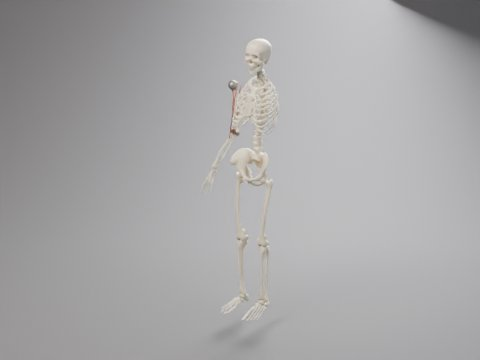

In [7]:
if BLENDER:
    thin = OUT / "elbow_paths"
    render("--env", "myoElbowPose1D6MRandom-v0", "--random", "--seconds", "0.2", "--preview",
           "--muscles", "paths", "--resolution", "480", "360", "--samples", "16", "--output", str(thin))
    show(thin / "preview.png", 480)

### Render a trained policy

Pass an SB3 `.zip` or an RSL-RL `.pt` (or a run directory) instead of `--random`. A checkpoint that
does not fit the env raises an error instead of falling back to random actions. Tutorials 1.2 and 2.2
show how to get checkpoints, for example the published baselines on Hugging Face.

```bash
python scripts/render_blender.py --env myoLegWalk-v0 --checkpoint path/to/model_1355.pt \
    --seconds 3 --output renders/walk --blender /path/to/blender
```

Keep each output folder together: `scene.blend` refers to the USD cache by a relative path. Open it in
Blender to change the camera, lights or materials and render again. See `docs/source/blender_rendering.rst`
for the full reference.